# Colab Setup

In [1]:
# Install required packages
!pip install yt-dlp ultralytics opencv-python tqdm numpy

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.

# Imports

In [2]:
import numpy as np
import cv2
import torch
import json
import random
from tqdm import tqdm
from ultralytics import YOLO, SAM
from collections import deque
import math
import matplotlib.pyplot as plt
from datetime import datetime
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#Path setup


In [3]:
# Set your path - UPDATE THIS to match your Google Drive structure
PATH = "drive/MyDrive/UW-MS-DS/CSE493G1/Final_Project/Github/swiftcounter-cv/experiments"

# Check if path exists and create data directory if needed
!ls {PATH}
!mkdir -p {PATH}/data

print(f"✅ Working directory: {PATH}")
print(f"📁 Data directory: {PATH}/data")

colab-setup-manav.ipynb      data		   video_download.py
colanb-setup-aravindh.ipynb  pipeline-manav.ipynb
✅ Working directory: drive/MyDrive/UW-MS-DS/CSE493G1/Final_Project/Github/swiftcounter-cv/experiments
📁 Data directory: drive/MyDrive/UW-MS-DS/CSE493G1/Final_Project/Github/swiftcounter-cv/experiments/data


#ROI Setup

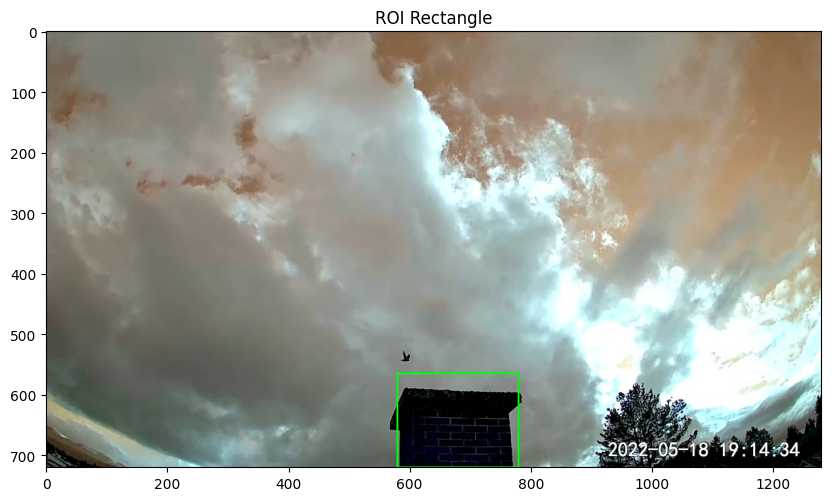

✅ ROI coordinates: [[580, 565], [780, 565], [780, 720], [580, 720]]


In [4]:
# Your existing ROI polygon (rectangle around chimney)
roi_polygon = np.array([
    [580, 565],  # top-left
    [780, 565],  # top-right
    [780, 720],  # bottom-right
    [580, 720],  # bottom-left
], dtype=int)

# Save ROI for use by tracker
roi_save_path = f"{PATH}/data/roi_polygon.npy"
np.save(roi_save_path, roi_polygon)

# Visualize ROI on reference frame (if you have one)
ref_img_path = f"{PATH}/data/reference_frame.jpg"
if os.path.exists(ref_img_path):
    frame = cv2.imread(ref_img_path)
    frame_vis = frame.copy()
    cv2.polylines(frame_vis, [roi_polygon], isClosed=True, color=(0,255,0), thickness=2)

    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
    plt.title("ROI Rectangle")
    plt.show()
else:
    print("📍 ROI polygon saved. Reference frame not found - will be created during first download.")

print(f"✅ ROI coordinates: {roi_polygon.tolist()}")

# Step 1: Helper functions for download

NOTE: Ensure that you download cookies.txt using a chrome extension and paste your cookies.txt file in `experiments/data/` for the download to work. It might need an eventual update once it expires, so regenerate and upload once that happens

In [5]:
def time_str_to_seconds(time_str):
    """Convert MM:SS format to seconds for yt-dlp"""
    if ':' in time_str:
        parts = time_str.split(':')
        if len(parts) == 2:
            minutes, seconds = parts
            return int(minutes) * 60 + int(seconds)
        elif len(parts) == 3:
            hours, minutes, seconds = parts
            return int(hours) * 3600 + int(minutes) * 60 + int(seconds)
    return int(time_str)

def time_str_to_filename(time_str):
    """Convert MM:SS to filename-safe format"""
    return time_str.replace(':', '-')

def download_video_segment_unique(video_url, start_time, end_time, segment_name):
    """Download video segment with unique filename based on time range"""
    start_sec = time_str_to_seconds(start_time)
    end_sec = time_str_to_seconds(end_time)

    # Create unique filename: downloaded_video_0-05_to_0-16.mp4
    start_filename = time_str_to_filename(start_time)
    end_filename = time_str_to_filename(end_time)
    unique_filename = f"downloaded_video_{start_filename}_to_{end_filename}.mp4"
    unique_path = f"{PATH}/data/{unique_filename}"

    print(f"📥 Downloading segment '{segment_name}': {start_time} to {end_time}")
    print(f"   Time range: {start_sec}s to {end_sec}s")
    print(f"   Saving as: {unique_filename}")

    # Download using your video_download.py script
    download_cmd = f"cd {PATH}; python video_download.py --video-url {video_url} --start {start_sec} --end {end_sec}"
    !{download_cmd}

    # Rename the default output to our unique name
    default_path = f"{PATH}/data/downloaded_video.mp4"
    if os.path.exists(default_path):
        !mv "{default_path}" "{unique_path}"
        print(f"✅ Video saved as: {unique_filename}")
    else:
        print(f"⚠️ Warning: Default video file not found at {default_path}")

    return unique_path, unique_filename

# Test the naming function
print("🧪 Testing filename generation:")
test_segments = [("0:05", "0:16"), ("0:33", "0:54"), ("1:14", "1:35")]
for start, end in test_segments:
    start_fn = time_str_to_filename(start)
    end_fn = time_str_to_filename(end)
    filename = f"downloaded_video_{start_fn}_to_{end_fn}.mp4"
    print(f"  {start} to {end} → {filename}")

🧪 Testing filename generation:
  0:05 to 0:16 → downloaded_video_0-05_to_0-16.mp4
  0:33 to 0:54 → downloaded_video_0-33_to_0-54.mp4
  1:14 to 1:35 → downloaded_video_1-14_to_1-35.mp4


#Bird tracker class

In [16]:
# Conservative Bird Tracker Pipeline - Standalone Version
import numpy as np
import cv2
import torch
import json
import random
import math
from tqdm import tqdm
from ultralytics import YOLO, SAM
import os
from datetime import datetime

class ConservativeBirdTracker:
    """Conservative bird tracker - builds on the working solution"""

    def __init__(self, roi_polygon):
        self.roi_polygon = roi_polygon
        self.max_distance_threshold = 80
        self.bird_tracks = {}
        self.next_track_id = 1
        self.birds_entered_roi = set()
        self.frame_count = 0
        self.roi_entry_threshold = 0.15

    def point_in_polygon(self, point, polygon):
        """Check if a point is inside a polygon using ray casting algorithm"""
        x, y = point
        n = len(polygon)
        inside = False

        p1x, p1y = polygon[0]
        for i in range(1, n + 1):
            p2x, p2y = polygon[i % n]
            if y > min(p1y, p2y):
                if y <= max(p1y, p2y):
                    if x <= max(p1x, p2x):
                        if p1y != p2y:
                            xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                        if p1x == p2x or x <= xinters:
                            inside = not inside
            p1x, p1y = p2x, p2y

        return inside

    def get_mask_centroid(self, mask):
        """Calculate centroid of segmentation mask"""
        y_coords, x_coords = np.where(mask > 0)
        if len(x_coords) == 0:
            return None
        centroid_x = int(np.mean(x_coords))
        centroid_y = int(np.mean(y_coords))
        return (centroid_x, centroid_y)

    def calculate_distance(self, point1, point2):
        """Calculate Euclidean distance between two points"""
        return math.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

    def conservative_roi_detection(self, bird_mask):
        """Conservative ROI detection - multiple methods"""
        try:
            y_coords, x_coords = np.where(bird_mask > 0)
            if len(x_coords) == 0:
                return False, 0.0, {'empty_mask': True}

            # Method 1: Check if ANY pixel is in ROI (most accurate)
            roi_pixels = 0
            for i in range(0, len(x_coords), 2):  # Check every 2nd pixel for speed
                if self.point_in_polygon((x_coords[i], y_coords[i]), self.roi_polygon):
                    roi_pixels += 1

            if roi_pixels > 0:
                return True, 1.0, {'pixel_overlap': True}

            # Method 2: Check centroid with small buffer (5 pixels)
            centroid_x = int(np.mean(x_coords))
            centroid_y = int(np.mean(y_coords))

            for dx in [-5, 0, 5]:
                for dy in [-5, 0, 5]:
                    test_point = (centroid_x + dx, centroid_y + dy)
                    if self.point_in_polygon(test_point, self.roi_polygon):
                        return True, 0.8, {'buffered_centroid': True}

            # Method 3: Check if bird is very close to ROI edge (20 pixels)
            roi_min_x = np.min(self.roi_polygon[:, 0])
            roi_max_x = np.max(self.roi_polygon[:, 0])
            roi_min_y = np.min(self.roi_polygon[:, 1])
            roi_max_y = np.max(self.roi_polygon[:, 1])

            min_x, max_x = np.min(x_coords), np.max(x_coords)
            min_y, max_y = np.min(y_coords), np.max(y_coords)

            # Only if bird is very close to ROI boundary
            if (abs(min_x - roi_max_x) < 20 or abs(max_x - roi_min_x) < 20 or
                abs(min_y - roi_max_y) < 20 or abs(max_y - roi_min_y) < 20):
                return True, 0.5, {'proximity': True}

            return False, 0.0, {'no_detection': True}

        except Exception as e:
            print(f"ROI detection error: {e}")
            return False, 0.0, {'error': True}

    def update_tracks(self, bird_detections, frame_idx=0, total_frames=1000):
        """Conservative tracking"""
        self.frame_count += 1
        current_detections = []
        birds_in_roi_this_frame = 0

        # Process each detection
        for detection in bird_detections:
            mask = detection['mask']
            confidence = float(detection['confidence'])
            centroid = self.get_mask_centroid(mask)

            if centroid:
                in_roi, roi_confidence, methods = self.conservative_roi_detection(mask)
                if in_roi:
                    birds_in_roi_this_frame += 1

                current_detections.append({
                    'centroid': centroid,
                    'mask': mask,
                    'confidence': confidence,
                    'roi_confidence': roi_confidence,
                    'in_roi': in_roi,
                    'detection_methods': methods
                })

        # Track matching
        matched_tracks = set()
        new_detections = []

        for curr_data in current_detections:
            curr_centroid = curr_data['centroid']
            best_match_id = None
            min_distance = float('inf')

            for track_id, track_data in self.bird_tracks.items():
                if track_id in matched_tracks:
                    continue

                if len(track_data['centroid_history']) > 0:
                    last_centroid = track_data['centroid_history'][-1]
                    distance = self.calculate_distance(curr_centroid, last_centroid)

                    if distance < self.max_distance_threshold and distance < min_distance:
                        min_distance = distance
                        best_match_id = track_id

            if best_match_id is not None:
                # Update existing track
                matched_tracks.add(best_match_id)
                track_data = self.bird_tracks[best_match_id]
                track_data['centroid_history'].append(curr_centroid)
                track_data['last_seen'] = self.frame_count

                # Count if bird is in ROI and hasn't been counted yet
                if curr_data['in_roi'] and not track_data['entered_roi']:
                    if curr_data['roi_confidence'] >= self.roi_entry_threshold:
                        track_data['entered_roi'] = True
                        track_data['entry_location'] = curr_centroid
                        track_data['entry_frame'] = self.frame_count
                        self.birds_entered_roi.add(best_match_id)

                        method_names = [k for k, v in curr_data['detection_methods'].items() if v]
                        print(f"🐦 Bird #{best_match_id} entered ROI at frame {self.frame_count}")
                        print(f"   Entry location: {curr_centroid}")
                        print(f"   Confidence: {curr_data['confidence']:.2f}")
                        print(f"   ROI confidence: {curr_data['roi_confidence']:.2f}")
                        print(f"   Detection methods: {', '.join(method_names)}")
            else:
                new_detections.append(curr_data)

        # Create new tracks
        for new_data in new_detections:
            track_id = self.next_track_id
            entered_roi = new_data['in_roi'] and new_data['roi_confidence'] >= self.roi_entry_threshold

            self.bird_tracks[track_id] = {
                'centroid_history': [new_data['centroid']],
                'entered_roi': entered_roi,
                'last_seen': self.frame_count
            }

            if entered_roi:
                self.bird_tracks[track_id]['entry_location'] = new_data['centroid']
                self.bird_tracks[track_id]['entry_frame'] = self.frame_count
                self.birds_entered_roi.add(track_id)

                method_names = [k for k, v in new_data['detection_methods'].items() if v]
                print(f"🐦 NEW Bird #{track_id} entered ROI at frame {self.frame_count}")
                print(f"   Entry location: {new_data['centroid']}")
                print(f"   Confidence: {new_data['confidence']:.2f}")
                print(f"   ROI confidence: {new_data['roi_confidence']:.2f}")
                print(f"   Detection methods: {', '.join(method_names)}")

            self.next_track_id += 1

        # Conservative cleanup
        if frame_idx > total_frames - 30:
            cleanup_threshold = 50  # Don't clean up tracks near the end
        else:
            cleanup_threshold = 8   # Normal cleanup

        tracks_to_remove = []
        for track_id, track_data in self.bird_tracks.items():
            frames_since_seen = self.frame_count - track_data['last_seen']
            if frames_since_seen > cleanup_threshold and not track_data['entered_roi']:
                tracks_to_remove.append(track_id)

        for track_id in tracks_to_remove:
            del self.bird_tracks[track_id]

        # Debug output
        if birds_in_roi_this_frame > 0:
            end_zone = " [END-ZONE]" if frame_idx > total_frames - 30 else ""
            print(f"🔍 Frame {self.frame_count}: {len(bird_detections)} birds detected, "
                  f"{birds_in_roi_this_frame} in ROI, {len(self.bird_tracks)} active tracks{end_zone}")

    def process_end_of_video(self):
        """Conservative end-of-video processing"""
        print(f"\n🏁 End-of-video processing - checking {len(self.bird_tracks)} tracks...")

        final_counts_added = 0
        for track_id, track_data in self.bird_tracks.items():
            if not track_data['entered_roi']:
                # Check if any point in recent history was in ROI
                recent_frames = min(3, len(track_data['centroid_history']))
                roi_hits = 0

                for i in range(-recent_frames, 0):
                    if abs(i) <= len(track_data['centroid_history']):
                        centroid_idx = len(track_data['centroid_history']) + i
                        if centroid_idx >= 0:
                            centroid = track_data['centroid_history'][centroid_idx]
                            if self.point_in_polygon(centroid, self.roi_polygon):
                                roi_hits += 1

                if roi_hits > 0:
                    track_data['entered_roi'] = True
                    track_data['entry_location'] = track_data['centroid_history'][-1]
                    track_data['entry_frame'] = self.frame_count
                    self.birds_entered_roi.add(track_id)
                    final_counts_added += 1
                    print(f"🐦 FINAL: Bird #{track_id} counted (was in ROI {roi_hits}/{recent_frames} recent frames)")

        if final_counts_added > 0:
            print(f"✅ Added {final_counts_added} birds from end-of-video processing")
        else:
            print(f"ℹ️ No additional birds found at video end")

        return final_counts_added

    def get_count(self):
        """Get total count of birds that entered ROI"""
        return len(self.birds_entered_roi)

    def get_tracking_info(self):
        """Get tracking information"""
        return {
            'total_birds_entered': len(self.birds_entered_roi),
            'active_tracks': len(self.bird_tracks),
            'confirmed_entries': list(self.birds_entered_roi)
        }


def enhanced_yolo_detection(model, frame, device):
    """Slightly more aggressive YOLO detection"""
    results = model.predict(
        source=frame,
        device=device,
        conf=0.12,  # Slightly lower than default 0.25
        iou=0.4,    # Standard IoU
        max_det=80, # More detections but not excessive
        verbose=False
    )[0]

    return results


def conservative_bird_counting_pipeline(video_path, output_suffix=""):
    """Conservative pipeline - standalone version"""

    # Generate unique output names based on input
    base_name = os.path.splitext(os.path.basename(video_path))[0]
    output_video_path = f"{PATH}/data/conservative_output_{base_name}{output_suffix}.mp4"
    output_json_path = f"{PATH}/data/conservative_results_{base_name}{output_suffix}.json"

    # Load ROI polygon
    roi_path = f"{PATH}/data/roi_polygon.npy"
    roi_polygon = np.load(roi_path)
    print(f"📍 ROI loaded: {roi_polygon.shape[0]} vertices")

    # Initialize conservative bird tracker
    bird_tracker = ConservativeBirdTracker(roi_polygon)

    # Download YOLO model if needed
    if not os.path.exists("yolo11x.pt"):
        print("📥 Downloading YOLO model...")
        import subprocess
        subprocess.run(["wget", "https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11x.pt"],
                      check=True, capture_output=True)

    # Initialize models
    yolo = YOLO("yolo11x.pt")
    sam = SAM("sam2_b.pt")
    device = 0 if torch.cuda.is_available() else "cpu"
    print(f"🤖 Models loaded on device: {'cuda' if device == 0 else 'cpu'}")

    # Video setup
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f"📽️ Video loaded: {frame_count} frames @ {fps:.2f} FPS")
    print(f"🎯 Processing with CONSERVATIVE TRACKER")
    print(f"🔍 Multiple ROI detection methods + end-of-video processing")

    # Processing
    all_results = []
    frame_idx = 0

    with tqdm(total=frame_count, desc="Conservative bird counting") as pbar:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            try:
                # Create clean visualization
                vis_frame = frame.copy()

                # Draw ROI
                cv2.polylines(vis_frame, [roi_polygon], isClosed=True,
                             color=(0, 255, 255), thickness=2)
                cv2.putText(vis_frame, "CHIMNEY ROI",
                           (roi_polygon[0][0], roi_polygon[0][1] - 10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

                # Enhanced YOLO detection
                yolo_result = enhanced_yolo_detection(yolo, frame, device)

                # Filter for birds
                bird_boxes = []
                bird_confidences = []

                if yolo_result and yolo_result.boxes is not None:
                    for box in yolo_result.boxes:
                        try:
                            cls_id = int(box.cls)
                            confidence = float(box.conf.item()) if hasattr(box.conf, 'item') else float(box.conf)
                            if yolo.names[cls_id] == 'bird' and confidence >= 0.10:
                                bird_boxes.append(box.xyxy[0].cpu().numpy().tolist())
                                bird_confidences.append(confidence)
                        except:
                            continue

                bird_detections = []

                if bird_boxes:
                    try:
                        # SAM segmentation
                        sam_result = sam.predict(
                            source=frame,
                            bboxes=bird_boxes,
                            device=device,
                            verbose=False
                        )[0]

                        if sam_result.masks is not None:
                            masks = sam_result.masks.data.cpu().numpy()

                            for i, mask in enumerate(masks):
                                try:
                                    confidence = bird_confidences[i]

                                    bird_detections.append({
                                        'mask': mask,
                                        'confidence': confidence,
                                        'bbox': bird_boxes[i],
                                        'frame_idx': frame_idx
                                    })

                                    # Clean visualization
                                    color = [int(c) for c in np.random.randint(80, 220, 3)]
                                    mask_img = (mask * 255).astype(np.uint8)
                                    contours, _ = cv2.findContours(
                                        mask_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                                    )

                                    if contours:
                                        cv2.drawContours(vis_frame, contours, -1, color, 2)

                                        centroid = bird_tracker.get_mask_centroid(mask)
                                        if centroid and 0 <= centroid[0] < width and 0 <= centroid[1] < height:
                                            cv2.putText(vis_frame, f"{confidence:.2f}",
                                                       (centroid[0] + 5, centroid[1] - 5),
                                                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
                                except:
                                    continue
                    except Exception as e:
                        print(f"SAM error at frame {frame_idx}: {e}")

                # Update tracking
                bird_tracker.update_tracks(bird_detections, frame_idx, frame_count)

                # Display info
                tracking_info = bird_tracker.get_tracking_info()

                # Text overlay
                overlay = vis_frame.copy()
                cv2.rectangle(overlay, (5, 5), (450, 160), (0, 0, 0), -1)
                vis_frame = cv2.addWeighted(vis_frame, 0.8, overlay, 0.2, 0)

                cv2.putText(vis_frame, f"CONSERVATIVE BIRDS COUNTED: {tracking_info['total_birds_entered']}",
                           (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)

                cv2.putText(vis_frame, f"Frame: {frame_idx:03d} | Detected: {len(bird_detections):02d}",
                           (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

                cv2.putText(vis_frame, f"Active tracks: {tracking_info['active_tracks']:02d}",
                           (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

                cv2.putText(vis_frame, f"Method: Conservative ROI Detection",
                           (10, 115), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100, 255, 255), 1)

                progress_pct = (tracking_info['total_birds_entered'] / 43.0) * 100
                cv2.putText(vis_frame, f"Progress: {progress_pct:.1f}%",
                           (10, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (100, 255, 100), 1)

                # Show counted birds as blue dots at entry locations
                for track_id, track_data in bird_tracker.bird_tracks.items():
                    if track_data['entered_roi']:
                        if 'entry_location' in track_data:
                            entry_point = track_data['entry_location']
                        else:
                            # Fallback: use first centroid
                            entry_point = track_data['centroid_history'][0] if track_data['centroid_history'] else None

                        if entry_point and 0 <= entry_point[0] < width and 0 <= entry_point[1] < height:
                            cv2.circle(vis_frame, entry_point, 5, (255, 0, 0), -1)  # Blue dot
                            cv2.circle(vis_frame, entry_point, 8, (255, 0, 0), 2)   # Blue ring

                # Save results
                frame_results = {
                    'frame_idx': frame_idx,
                    'total_count': tracking_info['total_birds_entered'],
                    'birds_detected': len(bird_detections),
                    'active_tracks': tracking_info['active_tracks']
                }
                all_results.append(frame_results)

                # Write video
                out.write(vis_frame)
                frame_idx += 1
                pbar.update(1)

                if frame_idx > fps * 40:  # First 40 seconds
                    break

            except Exception as e:
                print(f"Error at frame {frame_idx}: {e}")
                frame_idx += 1
                pbar.update(1)
                continue

    cap.release()
    out.release()

    # End processing
    final_birds_added = bird_tracker.process_end_of_video()

    # Results
    final_count = bird_tracker.get_count()

    final_results = {
        'summary': {
            'video_file': os.path.basename(video_path),
            'total_frames_processed': frame_idx,
            'total_birds_counted': final_count,
            'birds_added_at_end': final_birds_added,
            'method': 'conservative_roi_detection'
        },
        'frame_by_frame': all_results,
        'roi_polygon': roi_polygon.tolist(),
        'parameters': {
            'roi_entry_threshold': bird_tracker.roi_entry_threshold,
            'max_distance_threshold': bird_tracker.max_distance_threshold,
            'detection_methods': ['pixel_overlap', 'buffered_centroid', 'proximity']
        }
    }

    with open(output_json_path, "w") as f:
        json.dump(final_results, f, indent=4)

    print(f"\n✅ CONSERVATIVE PROCESSING COMPLETE!")
    print(f"🐦 FINAL COUNT: {final_count} birds")
    print(f"📊 End-of-video adds: +{final_birds_added} birds")
    print(f"📹 Output video: {output_video_path}")
    print(f"📊 Results JSON: {output_json_path}")

    return final_results


def run_conservative_segment_test(segment_info, video_url):
    """Run conservative tracker on a single segment"""
    segment_name = segment_info['name']
    start_time = segment_info['start']
    end_time = segment_info['end']
    expected_count = segment_info.get('expected_count', None)

    print(f"\n🔄 CONSERVATIVE TEST: {segment_name}")
    print(f"⏱️ Time range: {start_time} to {end_time}")
    print("-" * 50)

    try:
        # Download video segment
        video_path, video_filename = download_video_segment_unique(
            video_url, start_time, end_time, segment_name
        )

        if not os.path.exists(video_path):
            raise Exception(f"Video file not found: {video_path}")

        # Run conservative tracker
        print(f"🎯 Running conservative analysis...")
        results = conservative_bird_counting_pipeline(
            video_path, output_suffix=f"_{segment_name}"
        )

        actual_count = results['summary']['total_birds_counted']
        end_of_video_adds = results['summary']['birds_added_at_end']

        # Calculate accuracy if expected count provided
        accuracy_info = {}
        if expected_count:
            accuracy_pct = (actual_count / expected_count) * 100
            difference = actual_count - expected_count
            accuracy_info = {
                'expected': expected_count,
                'actual': actual_count,
                'accuracy_percentage': accuracy_pct,
                'difference': difference,
                'end_of_video_adds': end_of_video_adds,
                'status': 'EXCELLENT' if accuracy_pct >= 90 else 'GOOD' if accuracy_pct >= 80 else 'NEEDS_WORK'
            }

        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'video_filename': video_filename,
            'conservative_count': actual_count,
            'end_of_video_adds': end_of_video_adds,
            'accuracy_info': accuracy_info,
            'full_results': results,
            'success': True
        }

    except Exception as e:
        print(f"❌ Error processing segment {segment_name}: {e}")
        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'conservative_count': 0,
            'error': str(e),
            'success': False
        }


def run_complete_conservative_analysis():
    """Run complete conservative analysis on all segments"""
    print("🚀 STARTING CONSERVATIVE BIRD TRACKER ANALYSIS")
    print("🎯 Using simple ROI overlap detection + end-of-video processing")
    print("🔍 Multiple detection methods: pixel overlap, buffered centroid, proximity")
    print("=" * 80)

    # Run all segment tests
    all_conservative_results = []

    for i, segment in enumerate(segments_to_test, 1):
        print(f"\n🔬 CONSERVATIVE TEST {i}/{len(segments_to_test)}")
        result = run_conservative_segment_test(segment, VIDEO_URL)
        all_conservative_results.append(result)

        # Show immediate results
        if result['success']:
            print(f"✅ {segment['name']}: {result['conservative_count']} birds detected")
            if result['accuracy_info'] and 'expected' in result['accuracy_info']:
                acc = result['accuracy_info']['accuracy_percentage']
                print(f"   Accuracy: {acc:.1f}% ({result['accuracy_info']['status']})")
                print(f"   End-of-video adds: +{result['end_of_video_adds']}")
        else:
            print(f"❌ {segment['name']}: Test failed")

        print("=" * 50)

    # Display comprehensive results
    print(f"\n" + "="*85)
    print(f"🎯 CONSERVATIVE TRACKER RESULTS SUMMARY")
    print(f"="*85)

    print(f"{'Segment':<18} {'Time Range':<15} {'Expected':<10} {'Conservative':<12} {'EOV+':<6} {'Accuracy':<12} {'Status':<15}")
    print(f"{'-'*18} {'-'*15} {'-'*10} {'-'*12} {'-'*6} {'-'*12} {'-'*15}")

    total_expected = 0
    total_conservative = 0
    successful_segments = 0

    for result in all_conservative_results:
        segment_name = result['segment_name'][:17]
        time_range = result['time_range'][:14]
        conservative_count = result['conservative_count']
        eov_adds = result.get('end_of_video_adds', 0)

        if result['success'] and result['accuracy_info'] and 'expected' in result['accuracy_info']:
            expected = result['accuracy_info']['expected']
            accuracy = f"{result['accuracy_info']['accuracy_percentage']:.1f}%"
            status = result['accuracy_info']['status']

            total_expected += expected
            total_conservative += conservative_count
            successful_segments += 1

            print(f"{segment_name:<18} {time_range:<15} {expected:<10} {conservative_count:<12} {eov_adds:<6} {accuracy:<12} {status:<15}")
        else:
            print(f"{segment_name:<18} {time_range:<15} {'N/A':<10} {conservative_count:<12} {eov_adds:<6} {'N/A':<12} {'FAILED':<15}")

    if successful_segments > 0:
        overall_accuracy = (total_conservative / total_expected) * 100
        print(f"{'-'*18} {'-'*15} {'-'*10} {'-'*12} {'-'*6} {'-'*12} {'-'*15}")
        print(f"{'TOTAL':<18} {'ALL':<15} {total_expected:<10} {total_conservative:<12} {'':<6} {overall_accuracy:.1f}{'%':<11} {'OVERALL':<15}")

        print(f"\n🎯 CONSERVATIVE ANALYSIS PERFORMANCE:")
        print(f"   📊 Total expected birds: {total_expected}")
        print(f"   🎯 Conservative detected: {total_conservative}")
        print(f"   📈 Overall accuracy: {overall_accuracy:.1f}%")
        print(f"   📉 Overall difference: {total_conservative - total_expected:+d} birds")
        print(f"   ✅ Successful tests: {successful_segments}/{len(all_conservative_results)}")

        if overall_accuracy >= 90:
            print(f"   🏆 Performance: OUTSTANDING! 🥇")
        elif overall_accuracy >= 85:
            print(f"   ⭐ Performance: EXCELLENT! ✨")
        elif overall_accuracy >= 75:
            print(f"   ✅ Performance: GOOD")
        else:
            print(f"   ⚠️ Performance: NEEDS IMPROVEMENT")

    # Save master results
    master_results = {
        'test_metadata': {
            'test_date': str(datetime.now()),
            'video_url': VIDEO_URL,
            'total_segments': len(segments_to_test),
            'tracker_type': 'conservative_roi_overlap'
        },
        'methodology': {
            'description': 'Simple ROI overlap detection with multiple methods',
            'detection_methods': ['pixel_overlap', 'buffered_centroid', 'proximity'],
            'end_of_video_processing': True
        },
        'segment_configuration': segments_to_test,
        'conservative_results': all_conservative_results
    }

    master_results_path = f"{PATH}/data/conservative_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(master_results_path, 'w') as f:
        json.dump(master_results, f, indent=4)

    print(f"\n💾 Conservative analysis saved: {master_results_path}")
    print(f"🎉 CONSERVATIVE ANALYSIS COMPLETE!")

    return all_conservative_results


print("✅ Conservative Bird Tracker loaded successfully!")
print("🎯 Features: Simple ROI overlap detection + end-of-video processing")
print("🔍 Multiple detection methods: pixel overlap, buffered centroid, proximity")
print("🚀 Ready to run: run_complete_conservative_analysis()")

✅ Conservative Bird Tracker loaded successfully!
🎯 Features: Simple ROI overlap detection + end-of-video processing
🔍 Multiple detection methods: pixel overlap, buffered centroid, proximity
🚀 Ready to run: run_complete_conservative_analysis()


In [17]:
def enhanced_yolo_detection(model, frame, device):
    """Slightly more aggressive YOLO detection - not too extreme"""
    results = model.predict(
        source=frame,
        device=device,
        conf=0.12,  # Slightly lower than default 0.25, but not extreme
        iou=0.4,    # Standard IoU
        max_det=80, # More detections but not excessive
        verbose=False
    )[0]

    return results

print("✅ Enhanced YOLO detection function loaded")

✅ Enhanced YOLO detection function loaded


In [27]:
# Conservative Bird Tracker Pipeline - Standalone Version
import numpy as np
import cv2
import torch
import json
import random
import math
from tqdm import tqdm
from ultralytics import YOLO, SAM
import os
from datetime import datetime

class ConservativeBirdTracker:
    """Conservative bird tracker - builds on the working solution"""

    def __init__(self, roi_polygon):
        self.roi_polygon = roi_polygon
        self.max_distance_threshold = 120  # Increased for faster birds
        self.bird_tracks = {}
        self.next_track_id = 1
        self.birds_entered_roi = set()
        self.frame_count = 0
        self.roi_entry_threshold = 0.1  # Lowered threshold since we have 3 methods now

        # Trajectory analysis parameters (same as behavioral tracker)
        self.trajectory_params = {
            'mu_down': 5.0,      # Expected downward movement (pixels)
            'sigma_down': 3.0,   # Standard deviation
            'min_frames': 3      # Minimum frames needed for trajectory analysis
        }

    def point_in_polygon(self, point, polygon):
        """Check if a point is inside a polygon using ray casting algorithm"""
        x, y = point
        n = len(polygon)
        inside = False

        p1x, p1y = polygon[0]
        for i in range(1, n + 1):
            p2x, p2y = polygon[i % n]
            if y > min(p1y, p2y):
                if y <= max(p1y, p2y):
                    if x <= max(p1x, p2x):
                        if p1y != p2y:
                            xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                        if p1x == p2x or x <= xinters:
                            inside = not inside
            p1x, p1y = p2x, p2y

        return inside

    def get_mask_centroid(self, mask):
        """Calculate centroid of segmentation mask"""
        y_coords, x_coords = np.where(mask > 0)
        if len(x_coords) == 0:
            return None
        centroid_x = int(np.mean(x_coords))
        centroid_y = int(np.mean(y_coords))
        return (centroid_x, centroid_y)

    def calculate_distance(self, point1, point2):
        """Calculate Euclidean distance between two points"""
        return math.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

    def conservative_roi_detection(self, bird_mask, track_data=None):
        """Conservative ROI detection with trajectory analysis"""
        try:
            y_coords, x_coords = np.where(bird_mask > 0)
            if len(x_coords) == 0:
                return False, 0.0, {'empty_mask': True}

            # Method 1: Check if ANY pixel is in ROI (most accurate)
            roi_pixels = 0
            for i in range(0, len(x_coords), 2):  # Check every 2nd pixel for speed
                if self.point_in_polygon((x_coords[i], y_coords[i]), self.roi_polygon):
                    roi_pixels += 1

            if roi_pixels > 0:
                return True, 1.0, {'pixel_overlap': True}

            # Method 2: Check centroid with small buffer (5 pixels)
            centroid_x = int(np.mean(x_coords))
            centroid_y = int(np.mean(y_coords))

            for dx in [-5, 0, 5]:
                for dy in [-5, 0, 5]:
                    test_point = (centroid_x + dx, centroid_y + dy)
                    if self.point_in_polygon(test_point, self.roi_polygon):
                        return True, 0.8, {'buffered_centroid': True}

            # Method 3: Trajectory-based analysis (NEW)
            if track_data and len(track_data.get('centroid_history', [])) >= self.trajectory_params['min_frames']:
                centroid_history = track_data['centroid_history']

                # Check if bird is moving downward in recent frames
                recent_centroids = centroid_history[-self.trajectory_params['min_frames']:]

                if len(recent_centroids) >= 2:
                    # Calculate vertical displacements (downward = positive)
                    vertical_movements = []
                    for i in range(1, len(recent_centroids)):
                        dy = recent_centroids[i][1] - recent_centroids[i-1][1]
                        vertical_movements.append(dy)

                    if vertical_movements:
                        avg_downward = sum(vertical_movements) / len(vertical_movements)

                        # If bird is moving downward (toward roost) and reasonably close to ROI
                        if avg_downward > 2.0:  # At least 2 pixels downward per frame
                            # Check if bird is near ROI (within reasonable distance)
                            roi_center_x = int(np.mean(self.roi_polygon[:, 0]))
                            roi_center_y = int(np.mean(self.roi_polygon[:, 1]))

                            distance_to_roi = ((centroid_x - roi_center_x)**2 + (centroid_y - roi_center_y)**2)**0.5

                            if distance_to_roi < 100:  # Within 100 pixels of ROI center
                                return True, 0.6, {'trajectory_downward': True, 'avg_movement': avg_downward}

            return False, 0.0, {'no_detection': True}

        except Exception as e:
            print(f"ROI detection error: {e}")
            return False, 0.0, {'error': True}

    def update_tracks(self, bird_detections, frame_idx=0, total_frames=1000):
        """Conservative tracking"""
        self.frame_count += 1
        current_detections = []
        birds_in_roi_this_frame = 0

        # Process each detection
        for detection in bird_detections:
            mask = detection['mask']
            confidence = float(detection['confidence'])
            centroid = self.get_mask_centroid(mask)

            if centroid:
                # For new detections, we don't have track history yet
                in_roi, roi_confidence, methods = self.conservative_roi_detection(mask, track_data=None)
                if in_roi:
                    birds_in_roi_this_frame += 1

                current_detections.append({
                    'centroid': centroid,
                    'mask': mask,
                    'confidence': confidence,
                    'roi_confidence': roi_confidence,
                    'in_roi': in_roi,
                    'detection_methods': methods
                })

        # Track matching
        matched_tracks = set()
        new_detections = []

        for curr_data in current_detections:
            curr_centroid = curr_data['centroid']
            best_match_id = None
            min_distance = float('inf')

            for track_id, track_data in self.bird_tracks.items():
                if track_id in matched_tracks:
                    continue

                if len(track_data['centroid_history']) > 0:
                    last_centroid = track_data['centroid_history'][-1]
                    distance = self.calculate_distance(curr_centroid, last_centroid)

                    if distance < self.max_distance_threshold and distance < min_distance:
                        min_distance = distance
                        best_match_id = track_id

            if best_match_id is not None:
                # Update existing track
                matched_tracks.add(best_match_id)
                track_data = self.bird_tracks[best_match_id]
                track_data['centroid_history'].append(curr_centroid)
                track_data['last_seen'] = self.frame_count

                # Re-check ROI status with trajectory analysis for existing tracks
                if not track_data['entered_roi']:
                    # Now we have track history, so we can use trajectory analysis
                    in_roi_with_trajectory, roi_conf_with_traj, methods_with_traj = self.conservative_roi_detection(
                        curr_data['mask'], track_data=track_data
                    )

                    # Use the better of the two ROI detections
                    if in_roi_with_trajectory and roi_conf_with_traj >= self.roi_entry_threshold:
                        track_data['entered_roi'] = True
                        track_data['entry_location'] = curr_centroid
                        track_data['entry_frame'] = self.frame_count
                        self.birds_entered_roi.add(best_match_id)

                        method_names = [k for k, v in methods_with_traj.items() if v]
                        print(f"🐦 Bird #{best_match_id} entered ROI at frame {self.frame_count}")
                        print(f"   Entry location: {curr_centroid}")
                        print(f"   Confidence: {curr_data['confidence']:.2f}")
                        print(f"   ROI confidence: {roi_conf_with_traj:.2f}")
                        print(f"   Detection methods: {', '.join(method_names)}")
                    elif curr_data['in_roi'] and curr_data['roi_confidence'] >= self.roi_entry_threshold:
                        # Fallback to original detection
                        track_data['entered_roi'] = True
                        track_data['entry_location'] = curr_centroid
                        track_data['entry_frame'] = self.frame_count
                        self.birds_entered_roi.add(best_match_id)

                        method_names = [k for k, v in curr_data['detection_methods'].items() if v]
                        print(f"🐦 Bird #{best_match_id} entered ROI at frame {self.frame_count}")
                        print(f"   Entry location: {curr_centroid}")
                        print(f"   Confidence: {curr_data['confidence']:.2f}")
                        print(f"   ROI confidence: {curr_data['roi_confidence']:.2f}")
                        print(f"   Detection methods: {', '.join(method_names)}")
            else:
                new_detections.append(curr_data)

        # Create new tracks
        for new_data in new_detections:
            track_id = self.next_track_id
            entered_roi = new_data['in_roi'] and new_data['roi_confidence'] >= self.roi_entry_threshold

            self.bird_tracks[track_id] = {
                'centroid_history': [new_data['centroid']],
                'entered_roi': entered_roi,
                'last_seen': self.frame_count
            }

            if entered_roi:
                self.bird_tracks[track_id]['entry_location'] = new_data['centroid']
                self.bird_tracks[track_id]['entry_frame'] = self.frame_count
                self.birds_entered_roi.add(track_id)

                method_names = [k for k, v in new_data['detection_methods'].items() if v]
                print(f"🐦 NEW Bird #{track_id} entered ROI at frame {self.frame_count}")
                print(f"   Entry location: {new_data['centroid']}")
                print(f"   Confidence: {new_data['confidence']:.2f}")
                print(f"   ROI confidence: {new_data['roi_confidence']:.2f}")
                print(f"   Detection methods: {', '.join(method_names)}")

            self.next_track_id += 1

        # NO TRACK CLEANUP - Keep all tracks alive throughout video
        # This allows birds to disappear and reappear without losing history

        # Debug output
        if birds_in_roi_this_frame > 0:
            end_zone = " [END-ZONE]" if frame_idx > total_frames - 30 else ""
            print(f"🔍 Frame {self.frame_count}: {len(bird_detections)} birds detected, "
                  f"{birds_in_roi_this_frame} in ROI, {len(self.bird_tracks)} total tracks{end_zone}")

    def process_end_of_video(self):
        """Conservative end-of-video processing"""
        print(f"\n🏁 End-of-video processing - checking {len(self.bird_tracks)} tracks...")

        final_counts_added = 0
        for track_id, track_data in self.bird_tracks.items():
            if not track_data['entered_roi']:
                # Check if any point in recent history was in ROI
                recent_frames = min(3, len(track_data['centroid_history']))
                roi_hits = 0

                for i in range(-recent_frames, 0):
                    if abs(i) <= len(track_data['centroid_history']):
                        centroid_idx = len(track_data['centroid_history']) + i
                        if centroid_idx >= 0:
                            centroid = track_data['centroid_history'][centroid_idx]
                            if self.point_in_polygon(centroid, self.roi_polygon):
                                roi_hits += 1

                if roi_hits > 0:
                    track_data['entered_roi'] = True
                    track_data['entry_location'] = track_data['centroid_history'][-1]
                    track_data['entry_frame'] = self.frame_count
                    self.birds_entered_roi.add(track_id)
                    final_counts_added += 1
                    print(f"🐦 FINAL: Bird #{track_id} counted (was in ROI {roi_hits}/{recent_frames} recent frames)")

        if final_counts_added > 0:
            print(f"✅ Added {final_counts_added} birds from end-of-video processing")
        else:
            print(f"ℹ️ No additional birds found at video end")

        return final_counts_added

    def get_count(self):
        """Get total count of birds that entered ROI"""
        return len(self.birds_entered_roi)

    def get_tracking_info(self):
        """Get tracking information"""
        return {
            'total_birds_entered': len(self.birds_entered_roi),
            'active_tracks': len(self.bird_tracks),
            'confirmed_entries': list(self.birds_entered_roi)
        }


def enhanced_yolo_detection(model, frame, device):
    """More aggressive YOLO detection for better bird capture"""
    results = model.predict(
        source=frame,
        device=device,
        conf=0.08,  # Lowered from 0.12 to catch more birds
        iou=0.4,    # Standard IoU
        max_det=100, # Increased from 80 to allow more detections
        verbose=False
    )[0]

    return results


def conservative_bird_counting_pipeline(video_path, output_suffix=""):
    """Conservative pipeline - standalone version"""

    # Generate unique output names based on input
    base_name = os.path.splitext(os.path.basename(video_path))[0]
    output_video_path = f"{PATH}/data/conservative_output_{base_name}{output_suffix}.mp4"
    output_json_path = f"{PATH}/data/conservative_results_{base_name}{output_suffix}.json"

    # Load ROI polygon
    roi_path = f"{PATH}/data/roi_polygon.npy"
    roi_polygon = np.load(roi_path)
    print(f"📍 ROI loaded: {roi_polygon.shape[0]} vertices")

    # Initialize conservative bird tracker
    bird_tracker = ConservativeBirdTracker(roi_polygon)

    # Download YOLO model if needed
    if not os.path.exists("yolo11x.pt"):
        print("📥 Downloading YOLO model...")
        import subprocess
        subprocess.run(["wget", "https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11x.pt"],
                      check=True, capture_output=True)

    # Initialize models
    yolo = YOLO("yolo11x.pt")
    sam = SAM("sam2_b.pt")
    device = 0 if torch.cuda.is_available() else "cpu"
    print(f"🤖 Models loaded on device: {'cuda' if device == 0 else 'cpu'}")

    # Video setup
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f"📽️ Video loaded: {frame_count} frames @ {fps:.2f} FPS")
    print(f"🎯 Processing with CONSERVATIVE TRACKER + TRAJECTORY ANALYSIS")
    print(f"🔍 ROI detection + downward movement analysis + no track cleanup")

    # Processing
    all_results = []
    frame_idx = 0

    with tqdm(total=frame_count, desc="Conservative bird counting") as pbar:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            try:
                # Create clean visualization
                vis_frame = frame.copy()

                # Draw ROI
                cv2.polylines(vis_frame, [roi_polygon], isClosed=True,
                             color=(0, 255, 255), thickness=2)
                cv2.putText(vis_frame, "CHIMNEY ROI",
                           (roi_polygon[0][0], roi_polygon[0][1] - 10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

                # Enhanced YOLO detection
                yolo_result = enhanced_yolo_detection(yolo, frame, device)

                # Filter for birds
                bird_boxes = []
                bird_confidences = []

                if yolo_result and yolo_result.boxes is not None:
                    for box in yolo_result.boxes:
                        try:
                            cls_id = int(box.cls)
                            confidence = float(box.conf.item()) if hasattr(box.conf, 'item') else float(box.conf)
                            if yolo.names[cls_id] == 'bird' and confidence >= 0.05:  # Lowered from 0.10
                                bird_boxes.append(box.xyxy[0].cpu().numpy().tolist())
                                bird_confidences.append(confidence)
                        except:
                            continue

                bird_detections = []

                if bird_boxes:
                    try:
                        # SAM segmentation
                        sam_result = sam.predict(
                            source=frame,
                            bboxes=bird_boxes,
                            device=device,
                            verbose=False
                        )[0]

                        if sam_result.masks is not None:
                            masks = sam_result.masks.data.cpu().numpy()

                            for i, mask in enumerate(masks):
                                try:
                                    confidence = bird_confidences[i]

                                    bird_detections.append({
                                        'mask': mask,
                                        'confidence': confidence,
                                        'bbox': bird_boxes[i],
                                        'frame_idx': frame_idx
                                    })

                                    # Clean visualization
                                    color = [int(c) for c in np.random.randint(80, 220, 3)]
                                    mask_img = (mask * 255).astype(np.uint8)
                                    contours, _ = cv2.findContours(
                                        mask_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                                    )

                                    if contours:
                                        cv2.drawContours(vis_frame, contours, -1, color, 2)

                                        centroid = bird_tracker.get_mask_centroid(mask)
                                        if centroid and 0 <= centroid[0] < width and 0 <= centroid[1] < height:
                                            cv2.putText(vis_frame, f"{confidence:.2f}",
                                                       (centroid[0] + 5, centroid[1] - 5),
                                                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
                                except:
                                    continue
                    except Exception as e:
                        print(f"SAM error at frame {frame_idx}: {e}")

                # Update tracking
                bird_tracker.update_tracks(bird_detections, frame_idx, frame_count)

                # Display info
                tracking_info = bird_tracker.get_tracking_info()

                # Text overlay
                overlay = vis_frame.copy()
                cv2.rectangle(overlay, (5, 5), (450, 180), (0, 0, 0), -1)
                vis_frame = cv2.addWeighted(vis_frame, 0.8, overlay, 0.2, 0)

                cv2.putText(vis_frame, f"CONSERVATIVE BIRDS COUNTED: {tracking_info['total_birds_entered']}",
                           (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)

                cv2.putText(vis_frame, f"Frame: {frame_idx:03d} | Detected: {len(bird_detections):02d}",
                           (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

                cv2.putText(vis_frame, f"Active tracks: {tracking_info['active_tracks']:02d}",
                           (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

                cv2.putText(vis_frame, f"Method: Conservative + Trajectory Analysis",
                           (10, 115), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100, 255, 255), 1)

                progress_pct = (tracking_info['total_birds_entered'] / 43.0) * 100
                cv2.putText(vis_frame, f"Progress: {progress_pct:.1f}%",
                           (10, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (100, 255, 100), 1)

                cv2.putText(vis_frame, f"GREEN dots = Entry locations of counted birds",
                           (10, 165), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

                # Show ONLY counted birds as small GREEN dots at their exact entry locations
                for track_id, track_data in bird_tracker.bird_tracks.items():
                    if track_data['entered_roi']:  # Only show dots for birds that were actually counted
                        if 'entry_location' in track_data:
                            entry_point = track_data['entry_location']

                            # Verify entry point is valid and within frame
                            if (entry_point and
                                isinstance(entry_point, (list, tuple)) and
                                len(entry_point) == 2 and
                                0 <= entry_point[0] < width and
                                0 <= entry_point[1] < height):

                                # Small GREEN dot for each counted bird (no ring)
                                cv2.circle(vis_frame, tuple(entry_point), 3, (0, 255, 0), -1)  # 3-pixel solid green dot

                                # Optional: Show track ID number next to dot (smaller text)
                                cv2.putText(vis_frame, f"#{track_id}",
                                           (entry_point[0] + 6, entry_point[1] - 3),
                                           cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 0), 1)

                # Save results
                frame_results = {
                    'frame_idx': frame_idx,
                    'total_count': tracking_info['total_birds_entered'],
                    'birds_detected': len(bird_detections),
                    'active_tracks': tracking_info['active_tracks']
                }
                all_results.append(frame_results)

                # Write video
                out.write(vis_frame)
                frame_idx += 1
                pbar.update(1)

                if frame_idx > fps * 40:  # First 40 seconds
                    break

            except Exception as e:
                print(f"Error at frame {frame_idx}: {e}")
                frame_idx += 1
                pbar.update(1)
                continue

    cap.release()
    out.release()

    # End processing
    final_birds_added = bird_tracker.process_end_of_video()

    # Results
    final_count = bird_tracker.get_count()

    final_results = {
        'summary': {
            'video_file': os.path.basename(video_path),
            'total_frames_processed': frame_idx,
            'total_birds_counted': final_count,
            'birds_added_at_end': final_birds_added,
            'method': 'conservative_roi_detection'
        },
        'frame_by_frame': all_results,
        'roi_polygon': roi_polygon.tolist(),
        'parameters': {
            'roi_entry_threshold': bird_tracker.roi_entry_threshold,
            'max_distance_threshold': bird_tracker.max_distance_threshold,
            'detection_methods': ['pixel_overlap', 'buffered_centroid', 'trajectory_downward'],
            'trajectory_params': bird_tracker.trajectory_params,
            'track_cleanup': 'disabled'
        }
    }

    with open(output_json_path, "w") as f:
        json.dump(final_results, f, indent=4)

    print(f"\n✅ CONSERVATIVE PROCESSING COMPLETE!")
    print(f"🐦 FINAL COUNT: {final_count} birds")
    print(f"📊 End-of-video adds: +{final_birds_added} birds")
    print(f"📹 Output video: {output_video_path}")
    print(f"📊 Results JSON: {output_json_path}")

    return final_results


def run_conservative_segment_test(segment_info, video_url):
    """Run conservative tracker on a single segment"""
    segment_name = segment_info['name']
    start_time = segment_info['start']
    end_time = segment_info['end']
    expected_count = segment_info.get('expected_count', None)

    print(f"\n🔄 CONSERVATIVE TEST: {segment_name}")
    print(f"⏱️ Time range: {start_time} to {end_time}")
    print("-" * 50)

    try:
        # Download video segment
        video_path, video_filename = download_video_segment_unique(
            video_url, start_time, end_time, segment_name
        )

        if not os.path.exists(video_path):
            raise Exception(f"Video file not found: {video_path}")

        # Run conservative tracker
        print(f"🎯 Running conservative analysis...")
        results = conservative_bird_counting_pipeline(
            video_path, output_suffix=f"_{segment_name}"
        )

        actual_count = results['summary']['total_birds_counted']
        end_of_video_adds = results['summary']['birds_added_at_end']

        # Calculate accuracy if expected count provided
        accuracy_info = {}
        if expected_count:
            accuracy_pct = (actual_count / expected_count) * 100
            difference = actual_count - expected_count
            accuracy_info = {
                'expected': expected_count,
                'actual': actual_count,
                'accuracy_percentage': accuracy_pct,
                'difference': difference,
                'end_of_video_adds': end_of_video_adds,
                'status': 'EXCELLENT' if accuracy_pct >= 90 else 'GOOD' if accuracy_pct >= 80 else 'NEEDS_WORK'
            }

        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'video_filename': video_filename,
            'conservative_count': actual_count,
            'end_of_video_adds': end_of_video_adds,
            'accuracy_info': accuracy_info,
            'full_results': results,
            'success': True
        }

    except Exception as e:
        print(f"❌ Error processing segment {segment_name}: {e}")
        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'conservative_count': 0,
            'error': str(e),
            'success': False
        }


def run_complete_conservative_analysis():
    """Run complete conservative analysis on all segments"""
    print("🚀 STARTING CONSERVATIVE BIRD TRACKER ANALYSIS")
    print("🎯 Using ROI detection + trajectory analysis + no track cleanup")
    print("🔍 Detection methods: pixel overlap, buffered centroid, downward trajectory")
    print("=" * 80)

    # Run all segment tests
    all_conservative_results = []

    for i, segment in enumerate(segments_to_test, 1):
        print(f"\n🔬 CONSERVATIVE TEST {i}/{len(segments_to_test)}")
        result = run_conservative_segment_test(segment, VIDEO_URL)
        all_conservative_results.append(result)

        # Show immediate results
        if result['success']:
            print(f"✅ {segment['name']}: {result['conservative_count']} birds detected")
            if result['accuracy_info'] and 'expected' in result['accuracy_info']:
                acc = result['accuracy_info']['accuracy_percentage']
                print(f"   Accuracy: {acc:.1f}% ({result['accuracy_info']['status']})")
                print(f"   End-of-video adds: +{result['end_of_video_adds']}")
        else:
            print(f"❌ {segment['name']}: Test failed")

        print("=" * 50)

    # Display comprehensive results
    print(f"\n" + "="*85)
    print(f"🎯 CONSERVATIVE TRACKER RESULTS SUMMARY")
    print(f"="*85)

    print(f"{'Segment':<18} {'Time Range':<15} {'Expected':<10} {'Conservative':<12} {'EOV+':<6} {'Accuracy':<12} {'Status':<15}")
    print(f"{'-'*18} {'-'*15} {'-'*10} {'-'*12} {'-'*6} {'-'*12} {'-'*15}")

    total_expected = 0
    total_conservative = 0
    successful_segments = 0

    for result in all_conservative_results:
        segment_name = result['segment_name'][:17]
        time_range = result['time_range'][:14]
        conservative_count = result['conservative_count']
        eov_adds = result.get('end_of_video_adds', 0)

        if result['success'] and result['accuracy_info'] and 'expected' in result['accuracy_info']:
            expected = result['accuracy_info']['expected']
            accuracy = f"{result['accuracy_info']['accuracy_percentage']:.1f}%"
            status = result['accuracy_info']['status']

            total_expected += expected
            total_conservative += conservative_count
            successful_segments += 1

            print(f"{segment_name:<18} {time_range:<15} {expected:<10} {conservative_count:<12} {eov_adds:<6} {accuracy:<12} {status:<15}")
        else:
            print(f"{segment_name:<18} {time_range:<15} {'N/A':<10} {conservative_count:<12} {eov_adds:<6} {'N/A':<12} {'FAILED':<15}")

    if successful_segments > 0:
        overall_accuracy = (total_conservative / total_expected) * 100
        print(f"{'-'*18} {'-'*15} {'-'*10} {'-'*12} {'-'*6} {'-'*12} {'-'*15}")
        print(f"{'TOTAL':<18} {'ALL':<15} {total_expected:<10} {total_conservative:<12} {'':<6} {overall_accuracy:.1f}{'%':<11} {'OVERALL':<15}")

        print(f"\n🎯 CONSERVATIVE ANALYSIS PERFORMANCE:")
        print(f"   📊 Total expected birds: {total_expected}")
        print(f"   🎯 Conservative detected: {total_conservative}")
        print(f"   📈 Overall accuracy: {overall_accuracy:.1f}%")
        print(f"   📉 Overall difference: {total_conservative - total_expected:+d} birds")
        print(f"   ✅ Successful tests: {successful_segments}/{len(all_conservative_results)}")

        if overall_accuracy >= 90:
            print(f"   🏆 Performance: OUTSTANDING! 🥇")
        elif overall_accuracy >= 85:
            print(f"   ⭐ Performance: EXCELLENT! ✨")
        elif overall_accuracy >= 75:
            print(f"   ✅ Performance: GOOD")
        else:
            print(f"   ⚠️ Performance: NEEDS IMPROVEMENT")

    # Save master results
    master_results = {
        'test_metadata': {
            'test_date': str(datetime.now()),
            'video_url': VIDEO_URL,
            'total_segments': len(segments_to_test),
            'tracker_type': 'conservative_roi_overlap'
        },
        'methodology': {
            'description': 'ROI detection + trajectory analysis + no track cleanup',
            'detection_methods': ['pixel_overlap', 'buffered_centroid', 'trajectory_downward'],
            'end_of_video_processing': True,
            'track_cleanup': False
        },
        'segment_configuration': segments_to_test,
        'conservative_results': all_conservative_results
    }

    master_results_path = f"{PATH}/data/conservative_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(master_results_path, 'w') as f:
        json.dump(master_results, f, indent=4)

    print(f"\n💾 Conservative analysis saved: {master_results_path}")
    print(f"🎉 CONSERVATIVE ANALYSIS COMPLETE!")

    return all_conservative_results


print("✅ Conservative Bird Tracker loaded successfully!")
print("🎯 Features: ROI detection + trajectory analysis + no track cleanup")
print("🔍 Detection methods: pixel overlap, buffered centroid, downward trajectory")
print("🟢 Visualization: Small GREEN dots show exact entry locations")
print("🚀 Ready to run: run_complete_conservative_analysis()")

✅ Conservative Bird Tracker loaded successfully!
🎯 Features: ROI detection + trajectory analysis + no track cleanup
🔍 Detection methods: pixel overlap, buffered centroid, downward trajectory
🟢 Visualization: Small GREEN dots show exact entry locations
🚀 Ready to run: run_complete_conservative_analysis()


#Code below to draw bounding box, polygonselector does not work in colab, but does in jupyter!


In [28]:
# Segment test configuration
segments_to_test = [
    {"start": "0:05", "end": "0:16", "expected_count": 47, "name": "original_working"}]

# YouTube video URL
VIDEO_URL = "https://www.youtube.com/watch?v=mkquDCpPD9c"

print("📋 Configured test segments:")
for i, segment in enumerate(segments_to_test, 1):
    print(f"  {i}. {segment['name']}: {segment['start']} to {segment['end']} (expected: {segment.get('expected_count', 'N/A')} birds)")

📋 Configured test segments:
  1. original_working: 0:05 to 0:16 (expected: 47 birds)


## Step 2a: After downloading the video, run YOLO inference

In [30]:
def run_segment_test(segment_info, video_url):
    """Run tracker on a single segment with unique file handling"""
    segment_name = segment_info['name']
    start_time = segment_info['start']
    end_time = segment_info['end']
    expected_count = segment_info.get('expected_count', None)

    print(f"\n🔄 TESTING SEGMENT: {segment_name}")
    print(f"⏱️ Time range: {start_time} to {end_time}")
    print("-" * 50)

    try:
        # Download video segment with unique naming
        video_path, video_filename = download_video_segment_unique(
            video_url, start_time, end_time, segment_name
        )

        if not os.path.exists(video_path):
            raise Exception(f"Video file not found: {video_path}")

        # Run conservative tracker on this specific video file
        print(f"🤖 Running tracker on: {video_filename}")
        results = conservative_bird_counting_pipeline(video_path, output_suffix=f"_{segment_name}")

        actual_count = results['summary']['total_birds_counted']

        # Calculate accuracy if expected count provided
        accuracy_info = {}
        if expected_count:
            accuracy_pct = (actual_count / expected_count) * 100
            difference = actual_count - expected_count
            accuracy_info = {
                'expected': expected_count,
                'actual': actual_count,
                'accuracy_percentage': accuracy_pct,
                'difference': difference,
                'status': 'EXCELLENT' if accuracy_pct >= 90 else 'GOOD' if accuracy_pct >= 80 else 'NEEDS_WORK'
            }

        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'video_filename': video_filename,
            'model_count': actual_count,
            'accuracy_info': accuracy_info,
            'full_results': results,
            'success': True
        }

    except Exception as e:
        print(f"❌ Error in segment {segment_name}: {e}")
        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'video_filename': 'N/A',
            'model_count': 0,
            'accuracy_info': {'status': 'ERROR'},
            'error': str(e),
            'success': False
        }

def display_comprehensive_summary(all_results):
    """Display detailed summary of all test results"""
    print(f"\n" + "="*85)
    print(f"📊 COMPREHENSIVE TEST RESULTS SUMMARY")
    print(f"="*85)

    print(f"{'Segment':<18} {'Time Range':<15} {'Expected':<10} {'Actual':<10} {'Accuracy':<12} {'Status':<15}")
    print(f"{'-'*18} {'-'*15} {'-'*10} {'-'*10} {'-'*12} {'-'*15}")

    total_expected = 0
    total_actual = 0
    successful_tests = 0

    for result in all_results:
        segment_name = result['segment_name'][:17]
        time_range = result['time_range'][:14]
        model_count = result['model_count']

        if result['success'] and result['accuracy_info'] and 'expected' in result['accuracy_info']:
            expected = result['accuracy_info']['expected']
            accuracy = f"{result['accuracy_info']['accuracy_percentage']:.1f}%"
            status = result['accuracy_info']['status']

            total_expected += expected
            total_actual += model_count
            successful_tests += 1

            print(f"{segment_name:<18} {time_range:<15} {expected:<10} {model_count:<10} {accuracy:<12} {status:<15}")
        else:
            status = "ERROR" if not result['success'] else "MODEL_ONLY"
            print(f"{segment_name:<18} {time_range:<15} {'N/A':<10} {model_count:<10} {'N/A':<12} {status:<15}")

    # Overall statistics
    if successful_tests > 0:
        overall_accuracy = (total_actual / total_expected) * 100
        print(f"{'-'*18} {'-'*15} {'-'*10} {'-'*10} {'-'*12} {'-'*15}")
        print(f"{'TOTAL':<18} {'ALL':<15} {total_expected:<10} {total_actual:<10} {overall_accuracy:.1f}{'%':<11} {'OVERALL':<15}")

        print(f"\n🎯 FINAL PERFORMANCE ANALYSIS:")
        print(f"   📊 Total birds expected: {total_expected}")
        print(f"   🐦 Total birds detected: {total_actual}")
        print(f"   📈 Overall accuracy: {overall_accuracy:.1f}%")
        print(f"   📉 Total difference: {total_actual - total_expected:+d} birds")
        print(f"   ✅ Successful tests: {successful_tests}/{len(all_results)}")

        # Performance rating
        if overall_accuracy >= 90:
            print(f"   🏆 Overall Rating: OUTSTANDING! 🥇")
        elif overall_accuracy >= 85:
            print(f"   ⭐ Overall Rating: EXCELLENT! ✨")
        elif overall_accuracy >= 75:
            print(f"   ✅ Overall Rating: GOOD")
        else:
            print(f"   ⚠️ Overall Rating: NEEDS IMPROVEMENT")

    # File summary
    print(f"\n📁 GENERATED FILES:")
    for result in all_results:
        if result['success']:
            video_file = result.get('video_filename', 'N/A')
            segment_name = result['segment_name']
            print(f"   📹 Video: conservative_output_{video_file.replace('.mp4', '')}_{segment_name}.mp4")
            print(f"   📊 JSON:  conservative_results_{video_file.replace('.mp4', '')}_{segment_name}.json")

print("✅ Multi-segment testing functions loaded")

✅ Multi-segment testing functions loaded


In [31]:
# 🚀 EXECUTE COMPLETE MULTI-SEGMENT TEST SUITE
print("🚀 STARTING COMPREHENSIVE BIRD TRACKER TESTING")
print(f"📺 Video Source: {VIDEO_URL}")
print(f"🧪 Testing {len(segments_to_test)} segments with unique file management")
print("=" * 80)

# Run all segment tests
all_test_results = []

for i, segment in enumerate(segments_to_test, 1):
    print(f"\n🔬 TEST {i}/{len(segments_to_test)}")
    result = run_segment_test(segment, VIDEO_URL)
    all_test_results.append(result)

    # Show immediate results
    if result['success']:
        print(f"✅ {segment['name']}: {result['model_count']} birds detected")
        if result['accuracy_info'] and 'expected' in result['accuracy_info']:
            acc = result['accuracy_info']['accuracy_percentage']
            print(f"   Accuracy: {acc:.1f}% ({result['accuracy_info']['status']})")
    else:
        print(f"❌ {segment['name']}: Test failed")

    print("=" * 50)

# Display comprehensive results
display_comprehensive_summary(all_test_results)

# Save master results file
master_results = {
    'test_metadata': {
        'test_date': str(datetime.now()),
        'video_url': VIDEO_URL,
        'total_segments': len(segments_to_test),
        'tracker_version': 'conservative_v1'
    },
    'segment_configuration': segments_to_test,
    'test_results': all_test_results
}

master_results_path = f"{PATH}/data/master_test_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(master_results_path, 'w') as f:
    json.dump(master_results, f, indent=4)

print(f"\n💾 Master results saved: {master_results_path}")
print(f"🎉 COMPLETE TEST SUITE FINISHED!")

# Show file structure
print(f"\n📁 Generated file structure:")
!ls -la {PATH}/data/*.mp4 | head -10
!ls -la {PATH}/data/*.json | head -10

🚀 STARTING COMPREHENSIVE BIRD TRACKER TESTING
📺 Video Source: https://www.youtube.com/watch?v=mkquDCpPD9c
🧪 Testing 1 segments with unique file management

🔬 TEST 1/1

🔄 TESTING SEGMENT: original_working
⏱️ Time range: 0:05 to 0:16
--------------------------------------------------
📥 Downloading segment 'original_working': 0:05 to 0:16
   Time range: 5s to 16s
   Saving as: downloaded_video_0-05_to_0-16.mp4
📥 Downloading video from https://www.youtube.com/watch?v=mkquDCpPD9c to data/downloaded_video_raw.mp4
[youtube] Extracting URL: https://www.youtube.com/watch?v=mkquDCpPD9c
[youtube] mkquDCpPD9c: Downloading webpage
[youtube] mkquDCpPD9c: Downloading tv client config
[youtube] mkquDCpPD9c: Downloading tv player API JSON
[youtube] mkquDCpPD9c: Downloading ios player API JSON
[youtube] mkquDCpPD9c: Downloading m3u8 information
[info] mkquDCpPD9c: Downloading 1 format(s): 136
[download] Destination: data/downloaded_video_raw.mp4
[download] 100% of  123.95MiB in 00:00:02 at 48.91MiB/s
✅ 

Conservative bird counting:   1%|          | 3/264 [00:02<03:13,  1.35it/s]

🐦 Bird #1 entered ROI at frame 3
   Entry location: (605, 572)
   Confidence: 0.49
   ROI confidence: 1.00
   Detection methods: pixel_overlap
🔍 Frame 3: 1 birds detected, 1 in ROI, 1 total tracks


Conservative bird counting:   2%|▏         | 4/264 [00:03<02:29,  1.74it/s]

🔍 Frame 4: 1 birds detected, 1 in ROI, 1 total tracks


...

🔍 Frame 227: 2 birds detected, 1 in ROI, 54 total tracks


Conservative bird counting:  88%|████████▊ | 231/264 [01:29<00:06,  5.44it/s]

🔍 Frame 228: 2 birds detected, 1 in ROI, 54 total tracks


Conservative bird counting: 100%|██████████| 264/264 [01:30<00:00,  2.91it/s]



🏁 End-of-video processing - checking 54 tracks...
ℹ️ No additional birds found at video end

✅ CONSERVATIVE PROCESSING COMPLETE!
🐦 FINAL COUNT: 13 birds
📊 End-of-video adds: +0 birds
📹 Output video: drive/MyDrive/UW-MS-DS/CSE493G1/Final_Project/Github/swiftcounter-cv/experiments/data/conservative_output_downloaded_video_0-05_to_0-16_original_working.mp4
📊 Results JSON: drive/MyDrive/UW-MS-DS/CSE493G1/Final_Project/Github/swiftcounter-cv/experiments/data/conservative_results_downloaded_video_0-05_to_0-16_original_working.json
✅ original_working: 13 birds detected
   Accuracy: 27.7% (NEEDS_WORK)

📊 COMPREHENSIVE TEST RESULTS SUMMARY
Segment            Time Range      Expected   Actual     Accuracy     Status         
------------------ --------------- ---------- ---------- ------------ ---------------
original_working   0:05 to 0:16    47         13         27.7%        NEEDS_WORK     
------------------ --------------- ---------- ---------- ------------ ---------------
TOTAL           

In [12]:
# 🔍 OPTIONAL: Detailed analysis for specific segments
def analyze_segment_performance(segment_name):
    """Detailed analysis for a specific segment"""
    for result in all_test_results:
        if result['segment_name'] == segment_name:
            print(f"🔍 DETAILED ANALYSIS: {segment_name}")
            print("=" * 60)
            print(f"⏱️ Time range: {result['time_range']}")
            print(f"📁 Video file: {result.get('video_filename', 'N/A')}")
            print(f"🐦 Birds detected: {result['model_count']}")

            if result['accuracy_info'] and 'expected' in result['accuracy_info']:
                acc = result['accuracy_info']
                print(f"🎯 Expected count: {acc['expected']}")
                print(f"📊 Accuracy: {acc['accuracy_percentage']:.1f}%")
                print(f"📈 Difference: {acc['difference']:+d} birds")
                print(f"⭐ Performance: {acc['status']}")

                # Frame analysis if available
                if 'full_results' in result and result['full_results']:
                    frames = result['full_results'].get('frame_by_frame', [])
                    summary = result['full_results'].get('summary', {})

                    print(f"\n📽️ Processing Details:")
                    print(f"   Frames processed: {summary.get('total_frames_processed', 'N/A')}")
                    print(f"   End-of-video birds added: {summary.get('birds_added_at_end', 0)}")

                    if frames:
                        avg_detections = sum(f.get('birds_detected', 0) for f in frames) / len(frames)
                        max_detections = max(f.get('birds_detected', 0) for f in frames)
                        print(f"   Average detections/frame: {avg_detections:.1f}")
                        print(f"   Peak detections in frame: {max_detections}")

            return result

    print(f"❌ Segment '{segment_name}' not found")
    available = [r['segment_name'] for r in all_test_results]
    print(f"Available segments: {available}")
    return None

# Usage examples (uncomment to use):
# analyze_segment_performance('original_working')
# analyze_segment_performance('segment_2')
# analyze_segment_performance('segment_3')

print("💡 Use analyze_segment_performance('segment_name') for detailed analysis")
print("Available segments:", [r['segment_name'] for r in all_test_results])

💡 Use analyze_segment_performance('segment_name') for detailed analysis
Available segments: ['original_working', 'segment_2', 'segment_3']
